In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

drop_cols = [
    "difficulty",
    "srv_serror_rate", "dst_host_srv_serror_rate",
    "srv_rerror_rate", "dst_host_srv_rerror_rate",
]
categorical_cols = ["protocol_type", "service", "flag"]

In [2]:
train_df = pd.read_csv("../data/KDDTrain.txt", names=columns)
test_df = pd.read_csv("../data/KDDTest.txt", names=columns)

test_labels = test_df["label"].copy()

In [3]:
train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

train_df = train_df.drop(columns=drop_cols + ["label"])
test_df = test_df.drop(columns=drop_cols + ["label"])

In [4]:
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

In [5]:
X_train = train_df.drop(columns=["binary_label"])
y_train = train_df["binary_label"]
X_test = test_df.drop(columns=["binary_label"])
y_test = test_df["binary_label"]

In [6]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

In [7]:
model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=spw, random_state=42, eval_metric="logloss", n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
analysis = pd.DataFrame({
    "true_label":    test_labels.values,
    "true_binary":   y_test.values,
    "predicted":     y_pred,
})
analysis["correct"] = (analysis["true_binary"] == analysis["predicted"]).astype(int)
analysis["missed"]  = ((analysis["true_binary"] == 1) & (analysis["predicted"] == 0)).astype(int)

In [9]:
train_attack_types = set(pd.read_csv("../data/KDDTrain.txt", names=columns)["label"].unique())
test_attack_types  = set(test_labels.unique())
 
unseen_in_train = test_attack_types - train_attack_types
print("not in training data:")
print(sorted(unseen_in_train))

not in training data:
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


In [12]:
attack_analysis = (
    analysis[analysis["true_binary"] == 1]
    .groupby("true_label")
    .agg(
        total=("true_binary", "count"),
        caught=("correct", "sum"),
        missed=("missed", "sum"),
    )
    .assign(recall=lambda df: df["caught"] / df["total"])
    .sort_values("recall", ascending=True)
)
 
print("\n=== Per-Attack-Type Recall ===")
print(attack_analysis.to_string())


=== Per-Attack-Type Recall ===
                 total  caught  missed    recall
true_label                                      
sqlattack            2       0       2  0.000000
sendmail            14       0      14  0.000000
snmpgetattack      178       0     178  0.000000
snmpguess          331       0     331  0.000000
mailbomb           293       0     293  0.000000
loadmodule           2       0       2  0.000000
worm                 2       0       2  0.000000
rootkit             13       0      13  0.000000
guess_passwd      1231       0    1231  0.000000
ftp_write            3       0       3  0.000000
xlock                9       0       9  0.000000
imap                 1       0       1  0.000000
httptunnel         133      21     112  0.157895
named               17       3      14  0.176471
ps                  15       3      12  0.200000
xterm               13       3      10  0.230769
buffer_overflow     20       5      15  0.250000
xsnoop               4       1       

In [13]:
attack_analysis["seen_in_train"] = attack_analysis.index.map(
    lambda x: "seen" if x in train_attack_types else "UNSEEN"
)
print("\n(UNSEEN = attack type not present in training data at all)")
print(attack_analysis[["total","caught","missed","recall","seen_in_train"]].to_string())


(UNSEEN = attack type not present in training data at all)
                 total  caught  missed    recall seen_in_train
true_label                                                    
sqlattack            2       0       2  0.000000        UNSEEN
sendmail            14       0      14  0.000000        UNSEEN
snmpgetattack      178       0     178  0.000000        UNSEEN
snmpguess          331       0     331  0.000000        UNSEEN
mailbomb           293       0     293  0.000000        UNSEEN
loadmodule           2       0       2  0.000000          seen
worm                 2       0       2  0.000000        UNSEEN
rootkit             13       0      13  0.000000          seen
guess_passwd      1231       0    1231  0.000000          seen
ftp_write            3       0       3  0.000000          seen
xlock                9       0       9  0.000000        UNSEEN
imap                 1       0       1  0.000000          seen
httptunnel         133      21     112  0.157895        UN

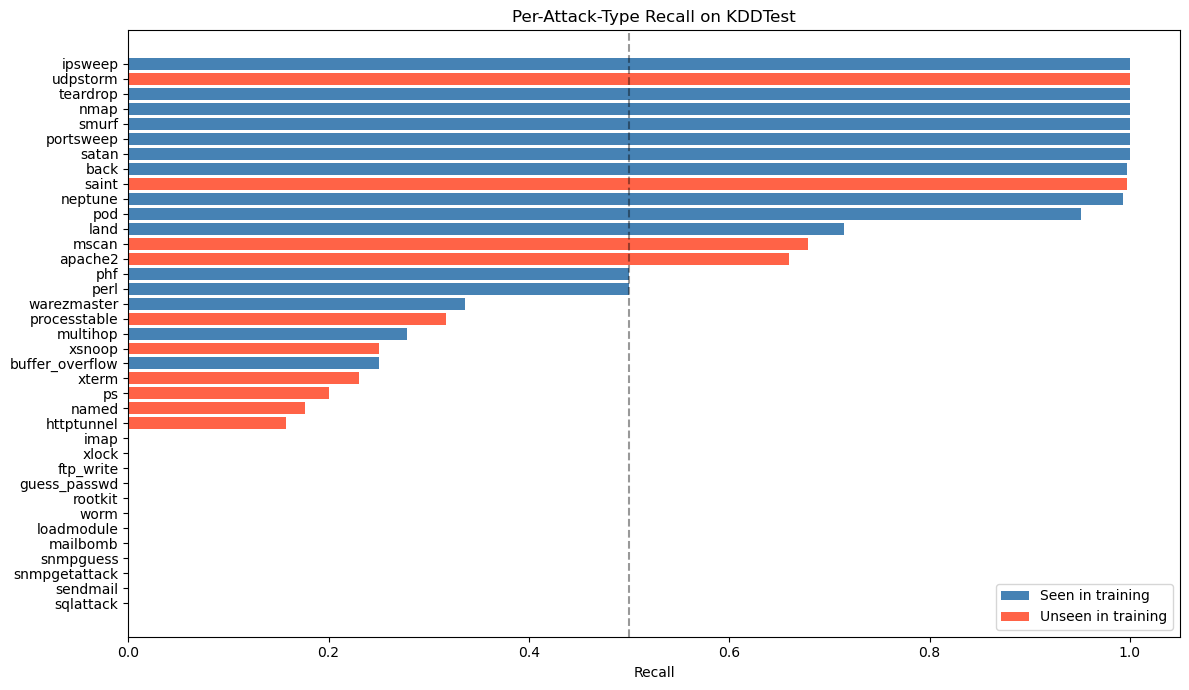

In [14]:
colors = attack_analysis["seen_in_train"].map({"seen": "steelblue", "UNSEEN": "tomato"})
 
plt.figure(figsize=(12, 7))
bars = plt.barh(attack_analysis.index, attack_analysis["recall"], color=colors)
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.4, label="50% recall line")
plt.xlabel("Recall")
plt.title("Per-Attack-Type Recall on KDDTest")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="steelblue", label="Seen in training"),
                   Patch(facecolor="tomato", label="Unseen in training")]
plt.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()

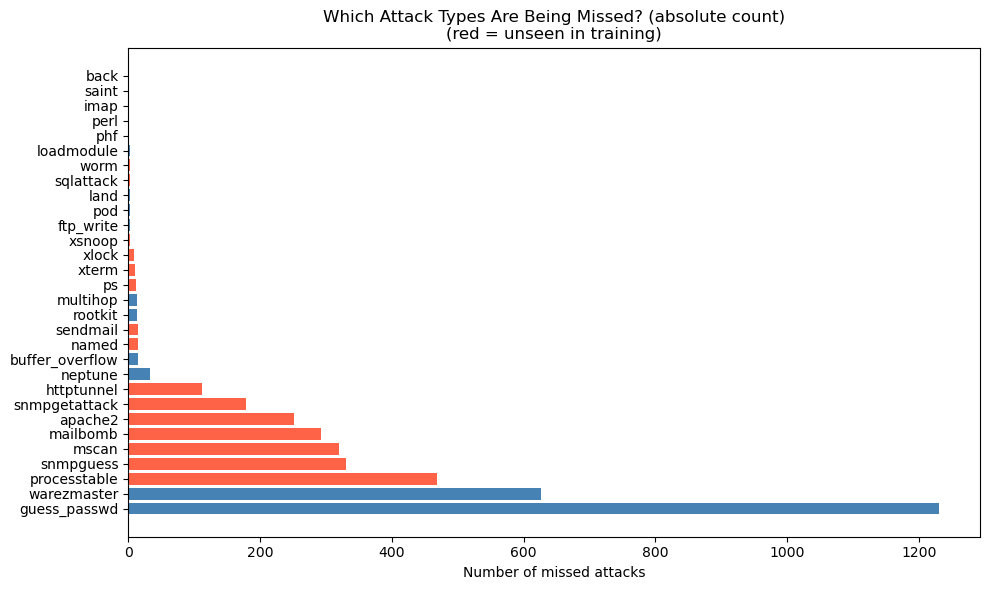

In [15]:
missed_only = attack_analysis[attack_analysis["missed"] > 0].sort_values("missed", ascending=False)
colors2 = missed_only["seen_in_train"].map({"seen": "steelblue", "UNSEEN": "tomato"})
 
plt.figure(figsize=(10, 6))
plt.barh(missed_only.index, missed_only["missed"], color=colors2)
plt.xlabel("Number of missed attacks")
plt.title("Which Attack Types Are Being Missed? (absolute count)\n(red = unseen in training)")
plt.tight_layout()

In [16]:
total_missed = analysis["missed"].sum()
missed_unseen = analysis[
    (analysis["missed"] == 1) &
    (analysis["true_label"].isin(unseen_in_train))
]["missed"].sum()
missed_seen = total_missed - missed_unseen
 
print(f"\n=== MISS BREAKDOWN ===")
print(f"Total attacks missed:           {total_missed}")
print(f"Missed because UNSEEN in train: {missed_unseen} ({100*missed_unseen/total_missed:.1f}%)")
print(f"Missed despite SEEN in train:   {missed_seen} ({100*missed_seen/total_missed:.1f}%)")
print("\nSaved per-attack recall and missed count plots.")


=== MISS BREAKDOWN ===
Total attacks missed:           3965
Missed because UNSEEN in train: 2020 (50.9%)
Missed despite SEEN in train:   1945 (49.1%)

Saved per-attack recall and missed count plots.
